# Project Overview 

This project explores the robustness of foundation models, specifically in the context of augmentations. We utilized the already split MIMIC Chest X-ray dataset (n = 238,909), focusing on AP/PA images for Cardiomegaly (n = 0.19) and Pneumothorax (n = 0.05). The dataset was divided into training and validation sets (70/30 split) for model development.

To analyze performance, we extracted RAD-DINO embeddings and used them to train a multiclass linear model with the training and validation data. The model then predicted embeddings for a separately derived test set, allowing us to assess generalization and stability.To assess robustness, various augmentation techniques were applied to the test set, including rotation (±5°, ±10°, ±15°), translation (0–25, 25–50, -25 to -50, 0 to -25 pixels), and zoom (80%, 90%, 110%, 120%). The model’s performance was evaluated by examining AUC scores for each class and analyzing corresponding losses. 

Training was conducted via Google Colab, while subsequent processing steps were completed in local environments to optimize computational efficiency. This research has been submitted for presentation at the Annual Meeting of RSNA 2025.

* 1

import libraries 

In [82]:
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
import torch.nn as nn
from torch.utils.data import Dataset
import os
import torch.optim as optim
from sklearn.metrics import roc_auc_score
from transformers import AutoModel, AutoImageProcessor
from PIL import Image
import torch
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import scipy.stats as stats

* 2

We load and filter the DataFrames to keep only relevant data (AP/PA and test splited data). Then, we merge them and handle missing or negative values to ensure consistency. Finally, we refine the dataset for focused analysis.


In [57]:
red_dino_df = pd.read_csv("C:\\Users\\USER\\Desktop\\Dr.khosravi\\labels.csv")
labels_df = pd.read_csv("C:\\Users\\USER\\Desktop\\Dr.khosravi\\mimic_cxr_metadata.csv")

print(red_dino_df.head())
print(labels_df.head())

   subject_id  study_id  Atelectasis  Cardiomegaly  Consolidation  Edema  \
0    10000032  50414267          NaN           NaN            NaN    NaN   
1    10000032  53189527          NaN           NaN            NaN    NaN   
2    10000032  53911762          NaN           NaN            NaN    NaN   
3    10000032  56699142          NaN           NaN            NaN    NaN   
4    10000764  57375967          NaN           NaN            1.0    NaN   

   Enlarged Cardiomediastinum  Fracture  Lung Lesion  Lung Opacity  \
0                         NaN       NaN          NaN           NaN   
1                         NaN       NaN          NaN           NaN   
2                         NaN       NaN          NaN           NaN   
3                         NaN       NaN          NaN           NaN   
4                         NaN       NaN          NaN           NaN   

   No Finding  Pleural Effusion  Pleural Other  Pneumonia  Pneumothorax  \
0         1.0               NaN            NaN 

In [60]:
labels_df = labels_df[labels_df['ViewPosition'].isin(['PA','AP'])]
labels_df = labels_df[labels_df['ViewCodeSequence_CodeMeaning'].isin(['postero-anterior','antero-posterior'])]
labels_df = labels_df[labels_df['Split'].isin(['test'])]
labels_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3388 entries, 1826 to 376663
Data columns (total 18 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   dicom_id                                    3388 non-null   object 
 1   subject_id                                  3388 non-null   int64  
 2   study_id                                    3388 non-null   int64  
 3   PerformedProcedureStepDescription           3115 non-null   object 
 4   ViewPosition                                3388 non-null   object 
 5   Rows                                        3388 non-null   int64  
 6   Columns                                     3388 non-null   int64  
 7   StudyDate                                   3388 non-null   int64  
 8   StudyTime                                   3388 non-null   float64
 9   ProcedureCodeSequence_CodeMeaning           3388 non-null   object 
 10  ViewCodeSequ

In [61]:
merged_df= labels_df.merge(red_dino_df, on='study_id')
print(merged_df.head())

                                       dicom_id  subject_id_x  study_id  \
0  abea5eb9-b7c32823-3a14c5ca-77868030-69c83139      10046166  50051329   
1  3a8a17fc-3cd357d9-83466363-91dc5a06-a401e5ed      10046166  51738740   
2  18f0fd6d-f513afc9-e4aa8de2-bc5ac0d6-ea3daaff      10046166  53492798   
3  7d5ef12b-34d86e32-207566d6-d5ed6f02-cd868f2c      10046166  53492798   
4  da33ac9f-b047f007-dd9e0ac7-81b4a35e-bb2b6b5b      10046166  56173345   

  PerformedProcedureStepDescription ViewPosition  Rows  Columns  StudyDate  \
0                CHEST (PA AND LAT)           AP  2544     3056   21331006   
1                CHEST (PA AND LAT)           AP  2544     3056   21330919   
2                    Performed Desc           PA  2021     1749   21330306   
3                    Performed Desc           PA  2021     2021   21330306   
4               CHEST (PORTABLE AP)           AP  2544     3056   21321207   

    StudyTime ProcedureCodeSequence_CodeMeaning  ...  \
0    4228.656           

In [62]:
merged_df=merged_df.fillna(0)
merged_df=merged_df.replace(-1,1)

merged_df_2 = merged_df[['dicom_id',
                         "Cardiomegaly",'Pneumothorax' ]]
merged_df_2 = merged_df_2.dropna(subset=['dicom_id'])

merged_df_2.reset_index(drop=True, inplace=True)

print(merged_df_2[["Cardiomegaly",'Pneumothorax']].value_counts())


Cardiomegaly  Pneumothorax
0.0           0.0             2278
1.0           0.0              985
0.0           1.0               99
1.0           1.0               26
Name: count, dtype: int64


* 3

We define get_feature to retrieve pre-extracted features, then build TensorDataset to load features and labels for Cardiomegaly and Pneumothorax. Using a structured DataFrame, we use test_dataset and wrap it in a DataLoader for efficient batch processing.

Our multilabel linear model includes a hidden layer, batch normalization, ReLU activation, dropout, and an output layer for stable predictions. To handle class imbalance, we implement Focal Loss, ensuring better learning from challenging examples.



In [63]:
def get_feature(directory_path, dataframe, idx):
    dicom_id = dataframe.iloc[idx]['dicom_id']
    file_path = os.path.join(directory_path, dicom_id + ".pt")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    return torch.load(file_path, weights_only=True)


class TensorDataset(Dataset):
    def __init__(self, dataframe, directory_path):
        self.dataframe = dataframe
        self.directory_path = directory_path

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        feature = get_feature(self.directory_path, self.dataframe, idx)
        raw_label = self.dataframe.iloc[idx][["Cardiomegaly", "Pneumothorax"]].values.astype(np.float32)
        label = torch.tensor(raw_label, dtype=torch.float)

        return feature, label



directory_path=r"C:\Users\USER\Desktop\Dr.khosravi\12_post_norm"
test_dataset = TensorDataset(merged_df_2, directory_path)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)


In [64]:
class MultilabelLinearModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_rate=0.5):
        super(MultilabelLinearModel, self).__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.batch_norm = nn.BatchNorm1d(hidden_size)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.output = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.hidden(x)
        x = self.batch_norm(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.output(x)
        return x


class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()



* 4

We load the trained multilinear model, set the device using CUDA, and map the saved weights for evaluation. To ensure consistency, we apply the same loss function and optimizer used during training on the train/validation split, maintaining alignment with the original model training strategy.We then evaluate the model’s performance on the original dataset without augmentation.

In [69]:
model_path = r"C:\Users\USER\Downloads\best_model.pth"


input_size = 768
hidden_size = 128
num_classes = 2

print(torch.cuda.is_available()) 
print(torch.cuda.get_device_name(0)) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultilabelLinearModel(input_size, hidden_size, num_classes).to(device)
model = torch.load(model_path, map_location=device , weights_only= False)

criterion = FocalLoss(alpha=1, gamma=2)
optimizer = optim.Adam(model.parameters(), lr=0.001)

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [70]:
model.eval()
test_running_loss = 0.0
test_preds = []
test_labels = []

test_loss_history = []
test_auc_per_class = []

with torch.no_grad():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)

           
            loss = criterion(outputs, labels)
            test_running_loss += loss.item()

            test_preds.append(torch.sigmoid(outputs).cpu().numpy())
            test_labels.append(labels.cpu().numpy())

test_loss = test_running_loss / len(test_loader)
test_preds = np.vstack(test_preds)
test_labels = np.vstack(test_labels)
test_auc = roc_auc_score(test_labels, test_preds, average=None)

test_loss_history.append(test_loss)
test_auc_per_class.append(test_auc)

print(f"test Loss: {test_loss:.4f}")
for i, auc in enumerate(test_auc):
        print(f"Class {i} test AUC: {auc:.4f}")


test Loss: 0.1230
Class 0 test AUC: 0.7563
Class 1 test AUC: 0.8152


* 5

Preparing the Data for augmentation.


In [65]:
testset_dicom = merged_df_2.copy()
testset_dicom = testset_dicom.reset_index(drop=True)

In [66]:
jpg_dir=r"C:\Users\USER\Desktop\MIMIC_Test_set\MIMIC_Test_set"
testset_dicom['ImagePath'] = testset_dicom['dicom_id'].apply(lambda x: os.path.join(jpg_dir, x + ".jpg"))

testset_dicom.head()

,dicom_id,Cardiomegaly,Pneumothorax,ImagePath
0,abea5eb9-b7c32823-3a14c5ca-77868030-69c83139,0.0,0.0,C:\Users\USER\Desktop\MIMIC_Test_set\MIMIC_Tes...
1,3a8a17fc-3cd357d9-83466363-91dc5a06-a401e5ed,0.0,0.0,C:\Users\USER\Desktop\MIMIC_Test_set\MIMIC_Tes...
2,18f0fd6d-f513afc9-e4aa8de2-bc5ac0d6-ea3daaff,0.0,0.0,C:\Users\USER\Desktop\MIMIC_Test_set\MIMIC_Tes...
3,7d5ef12b-34d86e32-207566d6-d5ed6f02-cd868f2c,0.0,0.0,C:\Users\USER\Desktop\MIMIC_Test_set\MIMIC_Tes...
4,da33ac9f-b047f007-dd9e0ac7-81b4a35e-bb2b6b5b,1.0,0.0,C:\Users\USER\Desktop\MIMIC_Test_set\MIMIC_Tes...


In [41]:
testset_dicom.iloc[0]['ImagePath']

'C:\\Users\\USER\\Desktop\\MIMIC_Test_set\\MIMIC_Test_set\\abea5eb9-b7c32823-3a14c5ca-77868030-69c83139.jpg'

In [42]:
testset_dicom.iloc[0]['dicom_id']

'abea5eb9-b7c32823-3a14c5ca-77868030-69c83139'

* 6

We apply custom transformations—translation, zoom, and rotation—while preserving image integrity. Augmented images are systematically saved with metadata linking them to Cardiomegaly and Pneumothorax labels. Finally, metadata is stored in CSV files for further analysis.

In [14]:
def apply_custom_transforms(image, translate=None, zoom=None, rotation=None, padding=0):
    image = F.resize(image, (518, 518))

    if translate: 
        image = F.affine(image, angle=0, translate=(translate[0], translate[1]), scale=1, shear=0, fill=padding)

    if zoom:
        image = F.affine(image, angle=0, translate=(0, 0), scale=zoom, shear=0, fill=padding)

    if rotation:
        image = F.rotate(image, angle=rotation, fill=padding)

    return image


In [21]:
translations = [(50, 25), (-25, -50), (0, 25), (0, -25)]
zoom_factors = [0.8, 0.9, 1.1, 1.2]
rotation_angles = [-15,-10, -5, 5, 10, 15]
padding = 0  
base_path = "../imagedata/Aug/cls"

In [22]:
os.makedirs(base_path, exist_ok=True)

for img_path in tqdm(testset_dicom['ImagePath'], desc="Processing Images"):
    image = Image.open(img_path).convert("RGB")
    dicom_id = os.path.basename(img_path).split(".")[0] 


    for translate in translations:
       folder_name = f"{base_path}/translation/{translate[0]}_{translate[1]}"
       os.makedirs(folder_name, exist_ok=True)
       transformed_image = apply_custom_transforms(image, translate=translate) 
       transformed_image.save(f"{folder_name}/{dicom_id}.jpg")


    for zoom in zoom_factors:
        folder_name = f"{base_path}/zoom/{zoom}"
        os.makedirs(folder_name, exist_ok=True)
        transformed_image = apply_custom_transforms(image, zoom=zoom)
        transformed_image.save(f"{folder_name}/{dicom_id}.jpg")

    for rotation in rotation_angles:
        folder_name = f"{base_path}/rotation/{rotation}"
        os.makedirs(folder_name, exist_ok=True)
        transformed_image = apply_custom_transforms(image, rotation=rotation)
        transformed_image.save(f"{folder_name}/{dicom_id}.jpg")



Processing Images: 100%|██████████| 3388/3388 [27:35<00:00,  2.05it/s]


In [ ]:
rot_Aug_data = pd.DataFrame(columns=["Augmented_Image", "Parameters", "Cardiomegaly", "Pneumothorax" , "transformation"])
zoom_Aug_data = pd.DataFrame(columns=["Augmented_Image", "Parameters", "Cardiomegaly", "Pneumothorax" , "transformation"])
trans_Aug_data = pd.DataFrame(columns=["Augmented_Image", "Parameters", "Cardiomegaly", "Pneumothorax" , "transformation"])



def get_metadata(image_id, testset_dicom):
    image_id_clean = os.path.splitext(image_id)[0].strip() 
    row = testset_dicom[testset_dicom["dicom_id"] == image_id_clean]
    if not row.empty: 
        return row.iloc[0]["Cardiomegaly"], row.iloc[0]["Pneumothorax"]
    else:
        print(f"Warning: {image_id_clean} not found in testset_dicom['dicom_id'].")
        return None, None 



for angle in rotation_angles:
    rotation_path = f"{base_path}/rotation/{angle}"
    
    if os.path.exists(rotation_path):
        for image_id in os.listdir(rotation_path):
            Augmented_Image = f"{rotation_path}/{image_id}"
            Cardiomegaly, Pneumothorax = get_metadata(image_id, testset_dicom)

            if Cardiomegaly is not None and Pneumothorax is not None: 
                rot_Aug_data.loc[len(rot_Aug_data)] = {
                    "Augmented_Image": Augmented_Image,
                    "Parameters": angle,
                    "Cardiomegaly": Cardiomegaly,
                    "Pneumothorax": Pneumothorax,
                    'transformation': "rotation"
                                                    }

for zoom_factor in zoom_factors:
    zoom_path = f"{base_path}/zoom/{zoom_factor}"
    
    if os.path.exists(zoom_path):
        for image_id in os.listdir(zoom_path):
            Augmented_Image = f"{zoom_path}/{image_id}"
            Cardiomegaly, Pneumothorax = get_metadata(image_id, testset_dicom)

            if Cardiomegaly is not None and Pneumothorax is not None:
                zoom_Aug_data.loc[len(zoom_Aug_data)] = {
                    "Augmented_Image": Augmented_Image,
                    "Parameters": zoom_factor,
                    "Cardiomegaly": Cardiomegaly,
                    "Pneumothorax": Pneumothorax, 
                    'transformation': "zoom"
                }


for translate in translations:
    trans_path = f"{base_path}/translation/{translate[0]}_{translate[1]}"
    
    if os.path.exists(trans_path):
        for image_id in os.listdir(trans_path):
            Augmented_Image = f"{trans_path}/{image_id}"
            Cardiomegaly, Pneumothorax = get_metadata(image_id, testset_dicom)

            if Cardiomegaly is not None and Pneumothorax is not None:
                trans_Aug_data.loc[len(trans_Aug_data)] = {
                    "Augmented_Image": Augmented_Image,
                    "Parameters": translate,
                    "Cardiomegaly": Cardiomegaly,
                    "Pneumothorax": Pneumothorax,
                    'transformation': "translation"
                }


rot_Aug_data.to_csv(f"{base_path}/Rotation_Metadata.csv", index=False)
zoom_Aug_data.to_csv(f"{base_path}/Zoom_Metadata.csv", index=False)
trans_Aug_data.to_csv(f"{base_path}/Translation_Metadata.csv", index=False)



making sure everything is all right.

In [26]:
print(len(rot_Aug_data) , "\n" ,len(zoom_Aug_data),'\n',len(trans_Aug_data))

20328 
 13552 
 13552


In [27]:
print((rot_Aug_data.head()) , "\n" ,(zoom_Aug_data.head()),'\n',(trans_Aug_data.head()))


                                     Augmented_Image  Parameters  \
0  ../imagedata/Aug/cls/rotation/-15/00005197-869...         -15   
1  ../imagedata/Aug/cls/rotation/-15/001bb54b-a4e...         -15   
2  ../imagedata/Aug/cls/rotation/-15/002ec547-399...         -15   
3  ../imagedata/Aug/cls/rotation/-15/005f2399-b87...         -15   
4  ../imagedata/Aug/cls/rotation/-15/00791688-1fa...         -15   

   Cardiomegaly  Pneumothorax transformation  
0           0.0           0.0       rotation  
1           0.0           0.0       rotation  
2           0.0           0.0       rotation  
3           0.0           0.0       rotation  
4           0.0           1.0       rotation   
                                      Augmented_Image  Parameters  \
0  ../imagedata/Aug/cls/zoom/0.8/00005197-869d72f...         0.8   
1  ../imagedata/Aug/cls/zoom/0.8/001bb54b-a4e0bb9...         0.8   
2  ../imagedata/Aug/cls/zoom/0.8/002ec547-39998a4...         0.8   
3  ../imagedata/Aug/cls/zoom/0.8/00

In [28]:
rot_Aug_groups = {param: df for param, df in rot_Aug_data.groupby("Parameters")}
zoom_Aug_groups = {param: df for param, df in zoom_Aug_data.groupby("Parameters")}
trans_Aug_groups = {param: df for param, df in trans_Aug_data.groupby("Parameters")}
for param, df in rot_Aug_groups.items():
    df.to_csv(f"C:/Users/USER/Desktop/imagedata/Aug/cls/rotation_{param}.csv", index=False)

for param, df in zoom_Aug_groups.items():
    df.to_csv(f"C:/Users/USER/Desktop/imagedata/Aug/cls/zoom_{param}.csv", index=False)

for param, df in trans_Aug_groups.items():
    df.to_csv(f"C:/Users/USER/Desktop/imagedata/Aug/cls/translation_{param}.csv", index=False)

* 7

We define AugmentedMIMICDataset to process augmented images, applying transformations and converting them to tensors. Each image is linked to its dicom_id for accurate mapping. The create_dirs() function organizes images by transformation type—rotation, zoom, translation—for efficient dataset management.

In [29]:
class AugmentedMIMICDataset(Dataset):
    def __init__(self, df, processor, transform=None):
        self.df = df
        self.processor = processor
        self.transform = transform  
       

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row["Augmented_Image"]
    
        dicom_id = os.path.basename(row['Augmented_Image'][:-4])

        try:
            image = Image.open(image_path).convert("RGB")

            if self.transform is not None:
                image = self.transform(image)

            processed_image = self.processor(image, return_tensors="pt")
            for k, v in processed_image.items():
                processed_image[k] = v.squeeze(0)

            return dicom_id, processed_image
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return None

transform = transforms.Compose([
    transforms.ToTensor(),        
])

In [30]:
def create_dirs(base_path):

    os.makedirs(f"{base_path}/cls/rotation", exist_ok=True)
    os.makedirs(f"{base_path}/cls/zoom", exist_ok=True)
    os.makedirs(f"{base_path}/cls/translation", exist_ok=True)


In [31]:
#to check if normalization is needed

image = Image.open('C:\\Users\\USER\\Desktop\\MIMIC_Test_set\\MIMIC_Test_set\\abea5eb9-b7c32823-3a14c5ca-77868030-69c83139.jpg')
image_array = np.array(image) / 255.0  

print("Min:", np.min(image_array), "Max:", np.max(image_array))
image.show()

Min: 0.0 Max: 1.0


* 8

Setting up our RAD-DINO model and its processor

In [32]:
repo = "microsoft/rad-dino"
rad_model = AutoModel.from_pretrained(repo)
processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino", do_rescale=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rad_model.to(device)
rad_model.eval()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06,

* 9

Batch Processing for Augmented Images

In [21]:
def create_dirs(base_path,  parameter):
    save_dir = os.path.join(base_path, str(parameter))
    os.makedirs(save_dir, exist_ok=True)
    return save_dir

def process_in_batches(df, processor, rad_model, device, base_path, batch_size=4, num_workers=2):
    if df.empty:
        print(f"Skipping {df.iloc[0]['transformation']} processing as DataFrame is empty.")
        return
    
    transformation = df.iloc[0]["transformation"]
    parameter = df.iloc[0]["Parameters"] 
    save_dir = create_dirs(base_path , parameter)

   
    Augmentedds = [sample for sample in AugmentedMIMICDataset(df, processor, transform=transform) if sample is not None]
    Augmenteddataloader = DataLoader(
        Augmentedds, batch_size=batch_size, shuffle=False, num_workers=num_workers,
        drop_last=False, prefetch_factor=2, persistent_workers=False
    )

    for batch in tqdm(Augmenteddataloader, desc=f"Processing {transformation} {parameter}"):
        if batch is None:
            continue

        dicom_ids, images_batch = batch
        for key in images_batch.keys():
            images_batch[key] = images_batch[key].to(device)
    

        with torch.inference_mode():
            outputs = rad_model(**images_batch, output_hidden_states=True)
            last_hidden_state = outputs.hidden_states[-1]

          
            for i, dicom_id in enumerate(dicom_ids):
                torch.save(last_hidden_state[i, 0, :].cpu(), os.path.join(base_path, f"{dicom_id}.pt"))

    torch.cuda.empty_cache() 


In [34]:
print(f"GPU Memory Used: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"GPU Memory Reserved: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")
print(f"GPU Utilization: {torch.cuda.memory_allocated() / torch.cuda.max_memory_allocated() * 100:.2f}%")


GPU Memory Used: 331.42 MB
GPU Memory Reserved: 382.00 MB
GPU Utilization: 100.00%


In [61]:
base_path=r"C:\Users\USER\Desktop\data\Aug_dino_embeddings\cls\zoom\0.8"
df=pd.read_csv(r"C:\Users\USER\Desktop\imagedata\Aug\cls\zoom_0.8.csv")

process_in_batches(df,
                    processor,
                      rad_model,
                        device,
                          base_path,
                            batch_size=2,
                              num_workers=8)


Processing zoom 0.8: 100%|██████████| 1694/1694 [04:24<00:00,  6.40it/s]


* 10

Preparing and Evaluating Our Multilinear Model on Augmented Data


In [9]:
print(model)

MultilabelLinearModel(
  (hidden): Linear(in_features=768, out_features=128, bias=True)
  (batch_norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (activation): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (output): Linear(in_features=128, out_features=2, bias=True)
)


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

MultilabelLinearModel(
  (hidden): Linear(in_features=768, out_features=128, bias=True)
  (batch_norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (activation): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (output): Linear(in_features=128, out_features=2, bias=True)
)

In [71]:
def get_feature(directory_path, dataframe, idx):
    dicom_id = dataframe.iloc[idx]['dicom_id']
    file_path = os.path.join(directory_path, dicom_id + ".pt")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    return torch.load(file_path, weights_only=True)

class TensorDataset(Dataset):
    def __init__(self, dataframe, directory_path):
        self.dataframe = dataframe
        self.directory_path = directory_path

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        feature = get_feature(self.directory_path, self.dataframe, idx)
        raw_label = self.dataframe.iloc[idx][["Cardiomegaly", "Pneumothorax"]].values.astype(np.float32)
        label = torch.tensor(raw_label, dtype=torch.float)

        return feature, label



class MultilabelLinearModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_rate=0.5):
        super(MultilabelLinearModel, self).__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.batch_norm = nn.BatchNorm1d(hidden_size)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.output = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.hidden(x)
        x = self.batch_norm(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.output(x)
        return x


class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()



In [72]:
main_root = Path(r"C:\Users\USER\Desktop\data\Aug_dino_embeddings\cls")
directory_paths = []
directory_paths2 = []


for d in main_root.iterdir():
    if d.is_dir(): 
        directory_paths.append(d)


for d in directory_paths:
    for d2 in d.iterdir():
        if d2.is_dir():  
            directory_paths2.append(d2)



print("Directories:", directory_paths)
print("Subdirectories:", directory_paths2)




Directories: [WindowsPath('C:/Users/USER/Desktop/data/Aug_dino_embeddings/cls/rotation'), WindowsPath('C:/Users/USER/Desktop/data/Aug_dino_embeddings/cls/translation'), WindowsPath('C:/Users/USER/Desktop/data/Aug_dino_embeddings/cls/zoom')]
Subdirectories: [WindowsPath('C:/Users/USER/Desktop/data/Aug_dino_embeddings/cls/rotation/-10'), WindowsPath('C:/Users/USER/Desktop/data/Aug_dino_embeddings/cls/rotation/-15'), WindowsPath('C:/Users/USER/Desktop/data/Aug_dino_embeddings/cls/rotation/-5'), WindowsPath('C:/Users/USER/Desktop/data/Aug_dino_embeddings/cls/rotation/10'), WindowsPath('C:/Users/USER/Desktop/data/Aug_dino_embeddings/cls/rotation/15'), WindowsPath('C:/Users/USER/Desktop/data/Aug_dino_embeddings/cls/rotation/5'), WindowsPath('C:/Users/USER/Desktop/data/Aug_dino_embeddings/cls/translation/-25--50'), WindowsPath('C:/Users/USER/Desktop/data/Aug_dino_embeddings/cls/translation/0--25'), WindowsPath('C:/Users/USER/Desktop/data/Aug_dino_embeddings/cls/translation/0-25'), WindowsPath

In [74]:

for dir in directory_paths2:
    Augtest_dataset = TensorDataset(testset_dicom, dir)
    AUGtest_loader = DataLoader(Augtest_dataset, batch_size=32, shuffle=True)

    
    model.eval()
    test_running_loss = 0.0
    test_preds = []
    test_labels = []

    test_loss_history = []
    test_auc_per_class = []

    with torch.no_grad():
        for features, labels in AUGtest_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)

           
            loss = criterion(outputs, labels)
            test_running_loss += loss.item()

            test_preds.append(torch.sigmoid(outputs).cpu().numpy())
            test_labels.append(labels.cpu().numpy())

    test_loss = test_running_loss / len(AUGtest_loader)
    test_preds = np.vstack(test_preds)
    test_labels = np.vstack(test_labels)
    test_auc = roc_auc_score(test_labels, test_preds, average=None)

    test_loss_history.append(test_loss)
    test_auc_per_class.append(test_auc)


    print(f"Augmented test {'/'.join(dir.parts[-2:])} Loss: {test_loss:.4f}")
    for i, auc in enumerate(test_auc):
        print(f"Class {i} Augmented test AUC: {auc:.4f}")



Augmented test rotation/-10 Loss: 8.8807
Class 0 Augmented test AUC: 0.7057
Class 1 Augmented test AUC: 0.7677
Augmented test rotation/-15 Loss: 9.1043
Class 0 Augmented test AUC: 0.7075
Class 1 Augmented test AUC: 0.7796
Augmented test rotation/-5 Loss: 8.7737
Class 0 Augmented test AUC: 0.6977
Class 1 Augmented test AUC: 0.7598
Augmented test rotation/10 Loss: 8.4694
Class 0 Augmented test AUC: 0.7059
Class 1 Augmented test AUC: 0.7292
Augmented test rotation/15 Loss: 8.6078
Class 0 Augmented test AUC: 0.7101
Class 1 Augmented test AUC: 0.7131
Augmented test rotation/5 Loss: 8.4713
Class 0 Augmented test AUC: 0.7019
Class 1 Augmented test AUC: 0.7408
Augmented test translation/-25--50 Loss: 8.6272
Class 0 Augmented test AUC: 0.7007
Class 1 Augmented test AUC: 0.7437
Augmented test translation/0--25 Loss: 8.6577
Class 0 Augmented test AUC: 0.6990
Class 1 Augmented test AUC: 0.7512
Augmented test translation/0-25 Loss: 8.7523
Class 0 Augmented test AUC: 0.6988
Class 1 Augmented test AU

* 11

Visualization the impact of rotation, translation, and zoom augmentations on AUC scores,

In [87]:

rotation_augmentation_accuracies = {
    "rotation": {
        "15": { "Cardiomegaly AUC": 0.7101, "Pneumothorax AUC": 0.7131},
        "10": { "Cardiomegaly AUC": 0.7059, "Pneumothorax AUC": 0.7292},
        "5": { "Cardiomegaly AUC": 0.7019, "Pneumothorax AUC": 0.7408},
        "0": { "Cardiomegaly AUC": 0.8545, "Pneumothorax AUC": 0.8495},  
        "-5": { "Cardiomegaly AUC": 0.6977, "Pneumothorax AUC": 0.7598},
        "-10": { "Cardiomegaly AUC": 0.7057, "Pneumothorax AUC": 0.7677},
        "-15": { "Cardiomegaly AUC": 0.7075, "Pneumothorax AUC": 0.7796},      
    },
}

translation_augmentation_accuracies = {
    "translation": {
        "25-50": { "Cardiomegaly AUC": 0.6994, "Pneumothorax AUC": 0.7522},
        "0-25": { "Cardiomegaly AUC": 0.6988, "Pneumothorax AUC": 0.7477},
        "0": { "Cardiomegaly AUC": 0.8545, "Pneumothorax AUC": 0.8495},  
        "0--25": { "Cardiomegaly AUC": 0.6990, "Pneumothorax AUC": 0.7512},
        "-25--50": { "Cardiomegaly AUC": 0.7007, "Pneumothorax AUC": 0.7437},
    },
}

zoom_augmentation_accuracies = {
    "zoom": {
        "1.2": { "Cardiomegaly AUC": 0.6993, "Pneumothorax AUC": 0.7444},
        "1.1": { "Cardiomegaly AUC": 0.6976, "Pneumothorax AUC": 0.7476},
        "0": { "Cardiomegaly AUC": 0.8545, "Pneumothorax AUC": 0.8495},  
        "0.9": { "Cardiomegaly AUC": 0.6979, "Pneumothorax AUC": 0.7495},
        "0.8": { "Cardiomegaly AUC": 0.6992, "Pneumothorax AUC": 0.7569},
    },
}


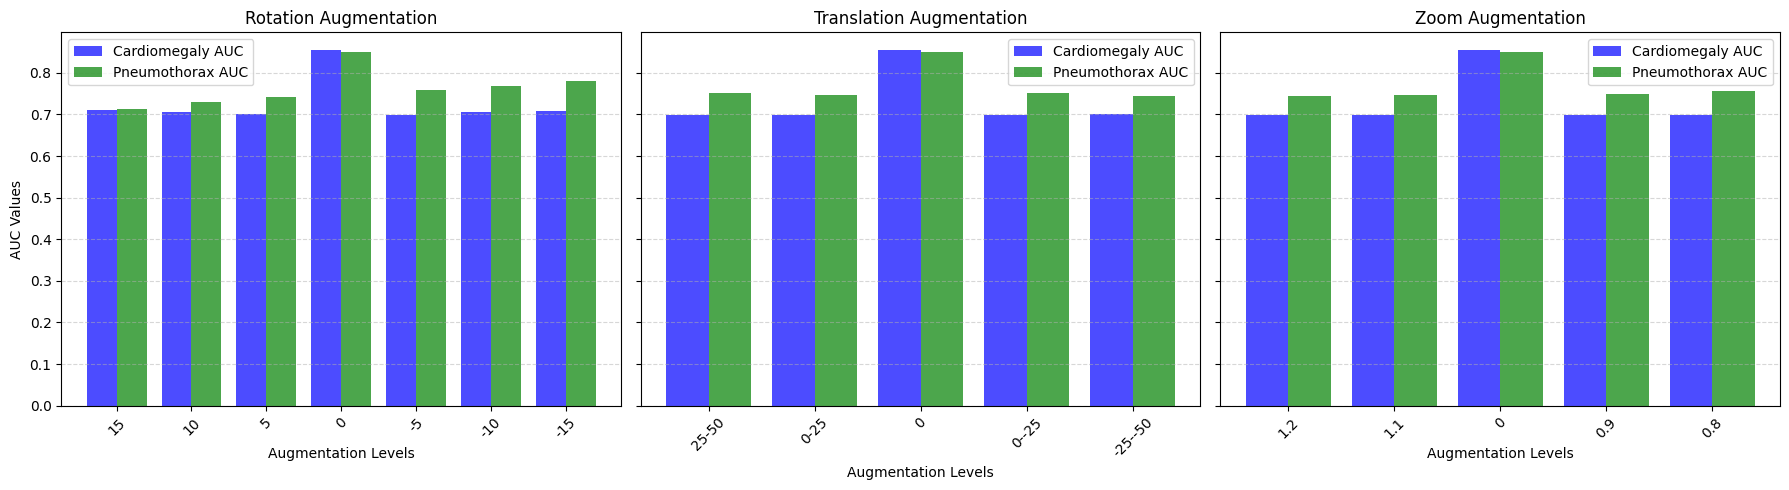

In [88]:
augmentations = {
    "Rotation": rotation_augmentation_accuracies["rotation"],
    "Translation": translation_augmentation_accuracies["translation"],
    "Zoom": zoom_augmentation_accuracies["zoom"],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (augment_type, augment_data) in zip(axes, augmentations.items()):
    categories = list(augment_data.keys())
    cardio_values = [augment_data[a].get("Cardiomegaly AUC", 0) for a in categories]
    pneum_values = [augment_data[a].get("Pneumothorax AUC", 0) for a in categories]
    
    bar_width = 0.4
    x_positions = np.arange(len(categories))

    ax.bar(x_positions - bar_width/2, cardio_values, bar_width, label="Cardiomegaly AUC", color="blue", alpha=0.7)
    ax.bar(x_positions + bar_width/2, pneum_values, bar_width, label="Pneumothorax AUC", color="green", alpha=0.7)

    ax.set_title(f"{augment_type} Augmentation")
    ax.set_xlabel("Augmentation Levels")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories, rotation=45)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)

axes[0].set_ylabel("AUC Values")

plt.tight_layout()
plt.show()


* 12

Statistical significance of each augmentation type was determined by paired t-tests against the non-augmented test set.

In [ ]:
# AUC values for test sets before augmentation
test_wo_aug = [0.7563, 0.8152]  # Class 0 (Cardiomegaly) & Class 1 (Pneumothorax)

# Augmented test set AUC values 
rotation_auc = {
    "15": [0.7101, 0.7131],
    "10": [0.7059, 0.7292],
    "5": [0.7019, 0.7408],
    "-5": [0.6977, 0.7598],
    "-10": [0.7057, 0.7677],
    "-15": [0.7075, 0.7796]
}

translation_auc = {
    "25-50": [0.6994, 0.7522],
    "0-25": [0.6988, 0.7477],
    "0--25": [0.6990, 0.7512],
    "-25--50": [0.7007, 0.7437]
}

zoom_auc = {
    "1.2": [0.6993, 0.7444],
    "1.1": [0.6976, 0.7476],
    "0.9": [0.6979, 0.7495],
    "0.8": [0.6992, 0.7569]
}

def paired_t_test_with_interpretation(aug_values, aug_type):
    for level, auc_values in aug_values.items():
        t_stat, p_value = stats.ttest_rel(auc_values, test_wo_aug)
        print(f"{aug_type} {level}° Augmentation - T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
        
        if p_value < 0.05:
            print(f"→ {aug_type} at {level}° significantly affects test performance (p < 0.05).")
        else:
            print(f"→ No significant difference for {aug_type} at {level}° (p ≥ 0.05).")
        print("-" * 60)

paired_t_test_with_interpretation(rotation_auc, "Rotation")
paired_t_test_with_interpretation(translation_auc, "Translation")
paired_t_test_with_interpretation(zoom_auc, "Zoom")


Rotation 15° Augmentation - T-statistic: -2.6530, P-value: 0.2295
→ No significant difference for Rotation at 15° (p ≥ 0.05).
------------------------------------------------------------
Rotation 10° Augmentation - T-statistic: -3.8315, P-value: 0.1625
→ No significant difference for Rotation at 10° (p ≥ 0.05).
------------------------------------------------------------
Rotation 5° Augmentation - T-statistic: -6.4400, P-value: 0.0981
→ No significant difference for Rotation at 5° (p ≥ 0.05).
------------------------------------------------------------
Rotation -5° Augmentation - T-statistic: -35.6250, P-value: 0.0179
→ Rotation at -5° significantly affects test performance (p < 0.05).
------------------------------------------------------------
Rotation -10° Augmentation - T-statistic: -31.6452, P-value: 0.0201
→ Rotation at -10° significantly affects test performance (p < 0.05).
------------------------------------------------------------
Rotation -15° Augmentation - T-statistic: -6.

Here are some models similar to **RAD-DINO** that can convert images into embeddings:

1. **DINOv2** – A **self-supervised vision transformer** that extracts **high-quality image embeddings**. RAD-DINO is built on this model, making it a strong alternative.
2. **BiomedCLIP** – A **medical imaging model** that generates embeddings by aligning **radiology images with text descriptions**.
3. **CXR-Foundation** – A **deep learning model** trained specifically for **chest X-ray embeddings**, similar to RAD-DINO.
4. **MedImageInsight** – A **foundation model** designed for **radiographic classification**, producing embeddings optimized for medical imaging tasks.
